In [126]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lokeshhate/zomato-lokesh-dataset/Dataset .csv


In [127]:
# resturant rating

In [128]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.model_selection import RandomizedSearchCV



In [129]:
#load dataset
df = pd.read_csv("/kaggle/input/datasets/lokeshhate/zomato-lokesh-dataset/Dataset .csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [130]:
#check dataset
df.shape
df.info()
df.describe()
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [131]:
drop_columns = [
    "Restaurant ID",
    "Restaurant Name",
    "Address",
    "Locality",
    "Locality Verbose",
    "Rating color",
    "Rating text"
]

df.drop(columns=drop_columns, errors="ignore", inplace=True)

In [132]:
#encoding
le = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])


In [133]:
# Features & Target
X = df.drop("Aggregate rating", axis=1)

y = df["Aggregate rating"]

In [134]:
# train and split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [135]:
# random forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


In [136]:
print(rf_pred)

[3.362 3.194 2.959 ... 2.977 4.298 4.208]


In [137]:
#Evaluate Random Forest
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")

print("MAE :", rf_mae)

print("RMSE :", rf_rmse)

print("R2 Score :", rf_r2)

Random Forest
MAE : 0.1918383045525902
RMSE : 0.29598508685047953
R2 Score : 0.9615101157234242


In [138]:
# xGboost
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [139]:
#evaluate the xgboost
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost")

print("MAE :", xgb_mae)

print("RMSE :", xgb_rmse)

print("R2 Score :", xgb_r2)


XGBoost
MAE : 0.18865521928782106
RMSE : 0.28672769628166656
R2 Score : 0.9638801251763374


In [140]:
#comarission table
comparison = pd.DataFrame({

    "Model":["Random Forest","XGBoost"],

    "MAE":[rf_mae,xgb_mae],

    "RMSE":[rf_rmse,xgb_rmse],

    "R2 Score":[rf_r2,xgb_r2]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Random Forest,0.191838,0.295985,0.96151
1,XGBoost,0.188655,0.286728,0.96388


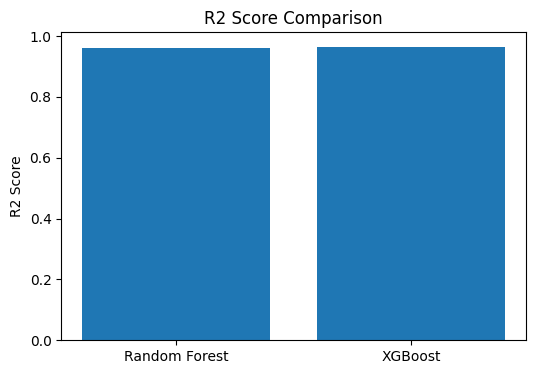

In [141]:
#R² Score Comparison
plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["R2 Score"])

plt.title("R2 Score Comparison")

plt.ylabel("R2 Score")

plt.show()


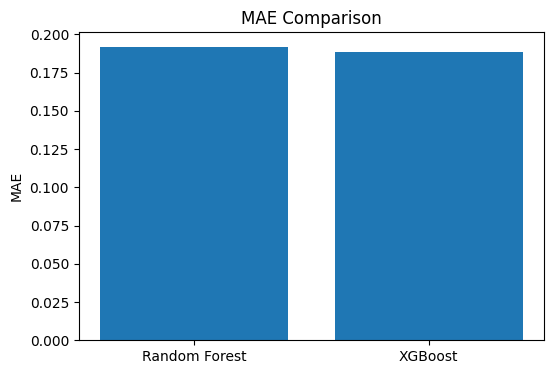

In [142]:
#Mae comparison
plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["MAE"])

plt.title("MAE Comparison")

plt.ylabel("MAE")

plt.show()


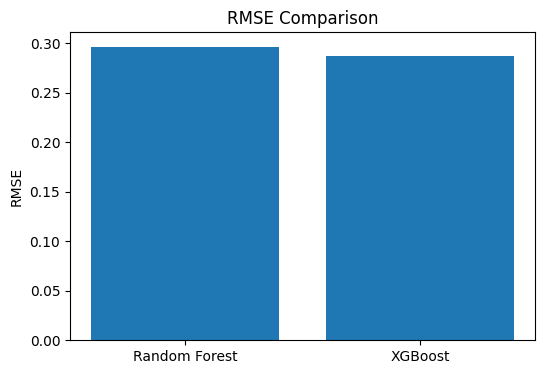

In [143]:
#RMSE Comparison
plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["RMSE"])

plt.title("RMSE Comparison")

plt.ylabel("RMSE")


plt.show()

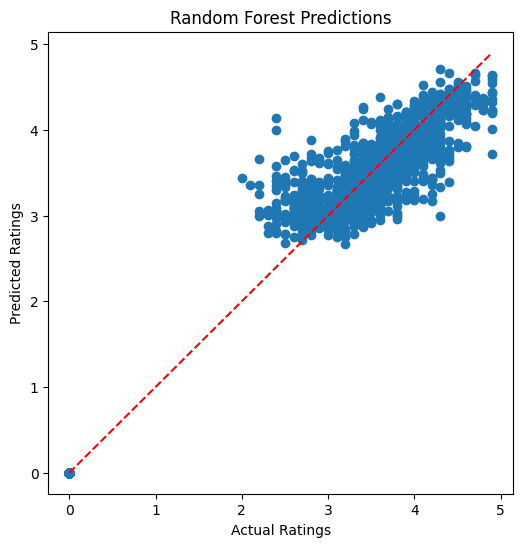

In [144]:
#Actual vs Predicted (Random Forest)
plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Ratings")

plt.ylabel("Predicted Ratings")

plt.title("Random Forest Predictions")

plt.show()

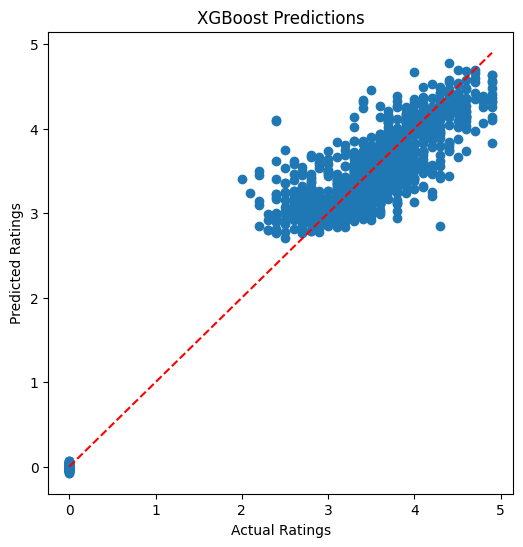

In [145]:
#Actual vs Predicted (XGBoost)
plt.figure(figsize=(6,6))

plt.scatter(y_test, xgb_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Ratings")

plt.ylabel("Predicted Ratings")

plt.title("XGBoost Predictions")

plt.show()

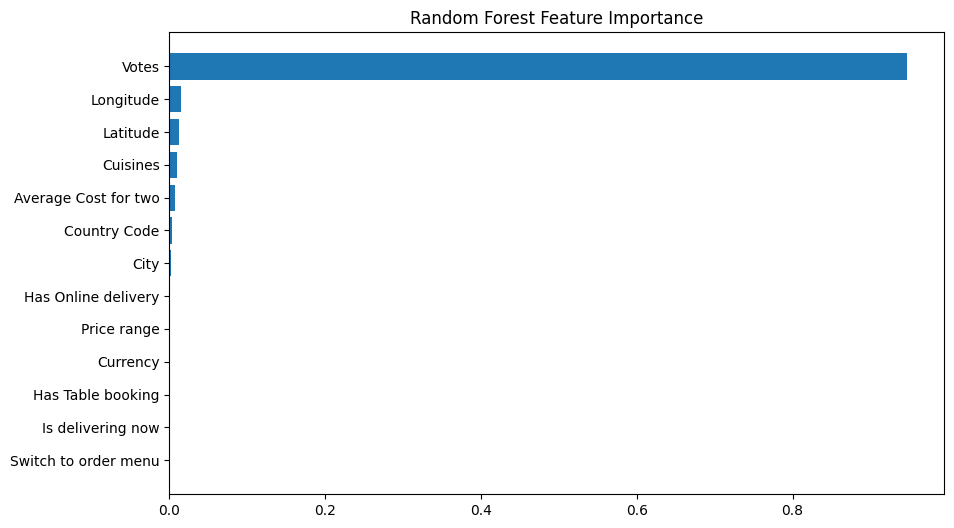

In [146]:
#Feature Importance (Random Forest)
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.show()

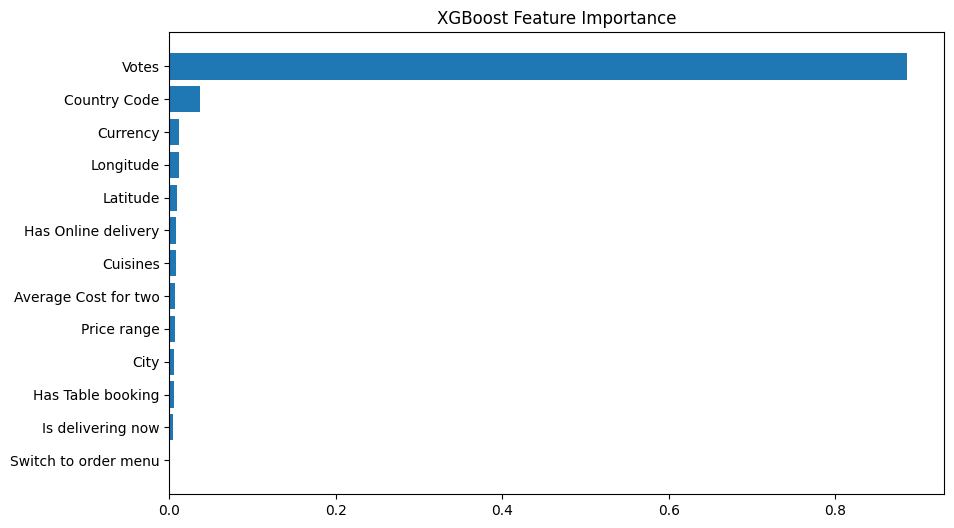

In [147]:
#Feature Importance (XGBoost)
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":xgb.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")

plt.show()

In [148]:
#Hyperparameter Tuning for Random Forest

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [149]:
# random search
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30, 40],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='r2')

In [150]:
#best parameters
print("Best Parameters:")
print(rf_random.best_params_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [151]:
# hyperparameter tuning for the xgboost
xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}


In [152]:
xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=xgb_params,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 9],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='r2')

In [153]:
print(xgb_random.best_params_)

{'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [154]:
# Comparison table after hypermater tuninng
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [rf_mae, xgb_mae],
    "RMSE": [rf_rmse, xgb_rmse],
    "R2 Score": [rf_r2, xgb_r2]
})

print(comparison)


           Model       MAE      RMSE  R2 Score
0  Random Forest  0.191838  0.295985   0.96151
1        XGBoost  0.188655  0.286728   0.96388


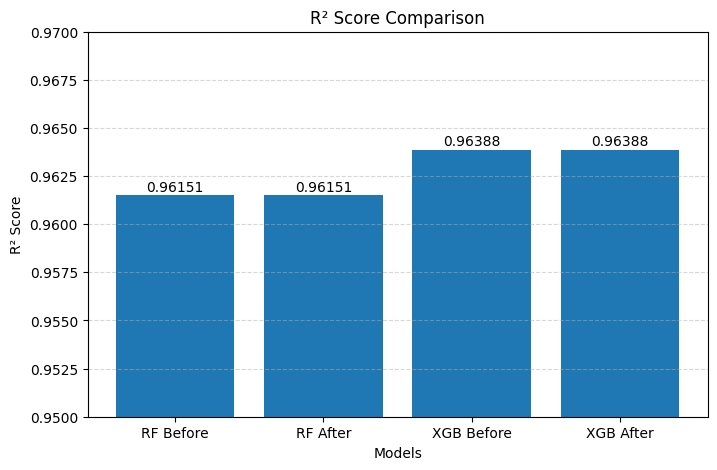

In [155]:
#Model Performance Comparison
   # Model Performance Comparison

comparison = pd.DataFrame({
    "Model": [
        "RF Before",
        "RF After",
        "XGB Before",
        "XGB After"
    ],
    "R2 Score": [
        0.96151,   # RF Before
        0.96151,   # RF After (Replace with your tuned RF R² if available)
        0.96388,   # XGB Before
        0.96388    # XGB After (Replace with your tuned XGB R² if available)
    ]
})

plt.figure(figsize=(8,5))

bars = plt.bar(comparison["Model"], comparison["R2 Score"])

plt.title("R² Score Comparison")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.ylim(0.95, 0.97)   # Better visualization

for i, v in enumerate(comparison["R2 Score"]):
    plt.text(i, v + 0.0002, f"{v:.5f}", ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

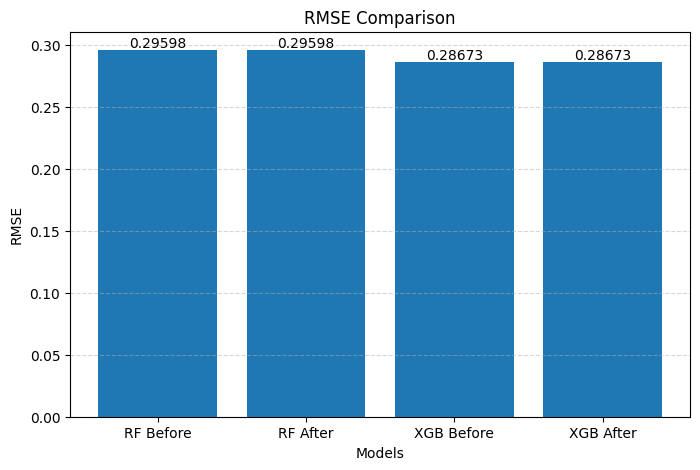

In [156]:
# MAE Comparison# Model Performance Comparison (RMSE)

comparison = pd.DataFrame({
    "Model": [
        "RF Before",
        "RF After",
        "XGB Before",
        "XGB After"
    ],
    "RMSE": [
        0.295985,   # RF Before
        0.295985,   # RF After (Replace with tuned RMSE)
        0.286728,   # XGB Before
        0.286728    # XGB After (Replace with tuned RMSE)
    ]
})

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["RMSE"])

plt.title("RMSE Comparison")
plt.xlabel("Models")
plt.ylabel("RMSE")

for i, v in enumerate(comparison["RMSE"]):
    plt.text(i, v + 0.002, f"{v:.5f}", ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


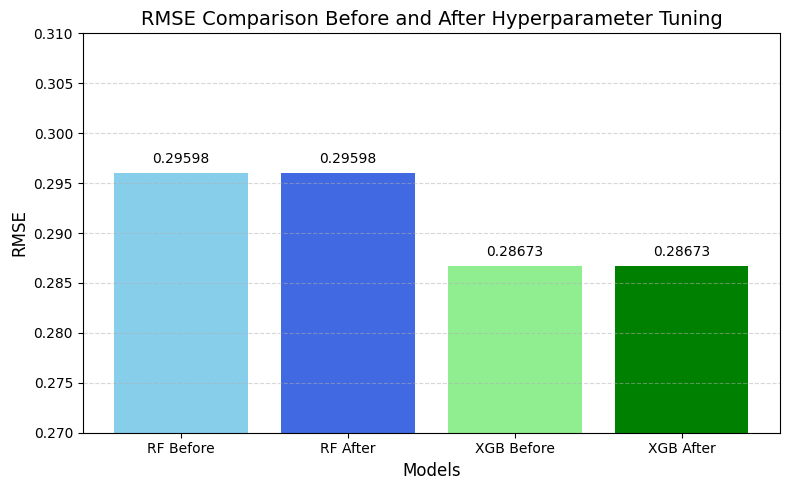

In [157]:
# RMSE Comparison

comparison = pd.DataFrame({
    "Model": ["RF Before", "RF After", "XGB Before", "XGB After"],
    "RMSE": [0.295985, 0.295985, 0.286728, 0.286728]
})

plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison["Model"],
    comparison["RMSE"],
    color=["skyblue", "royalblue", "lightgreen", "green"]
)

plt.title("RMSE Comparison Before and After Hyperparameter Tuning", fontsize=14)
plt.xlabel("Models", fontsize=12)
plt.ylabel("RMSE", fontsize=12)

plt.ylim(0.27, 0.31)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.001,
        f"{y:.5f}",
        ha='center',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

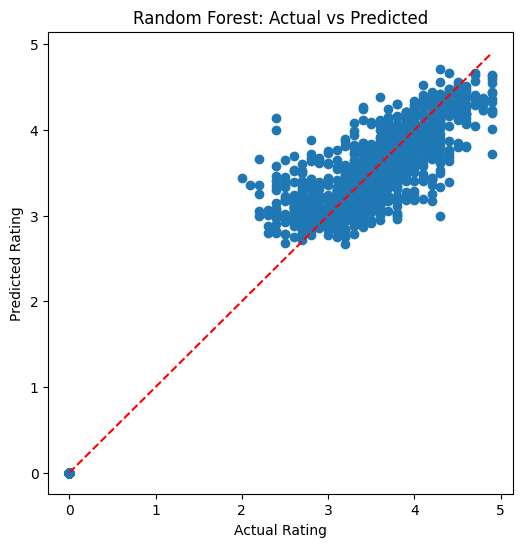

In [158]:
#Actual vs Predicted (Random Forest)
plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Random Forest: Actual vs Predicted")

plt.show()


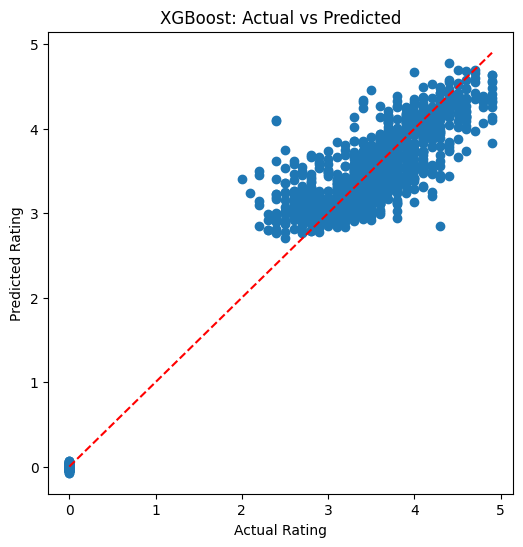

In [159]:
#Actual vs Predicted (XGBoost)
plt.figure(figsize=(6,6))

plt.scatter(y_test, xgb_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("XGBoost: Actual vs Predicted")

plt.show()

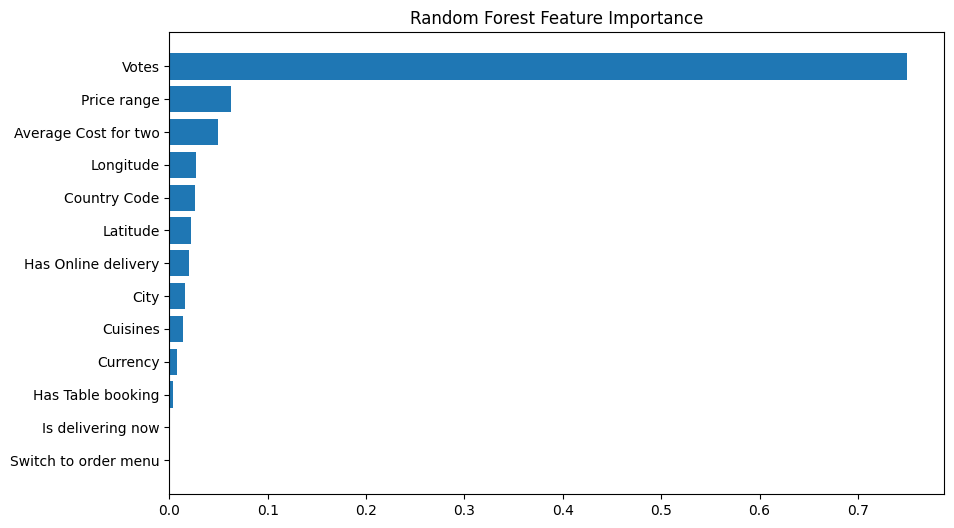

In [160]:
#Random Forest Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.show()

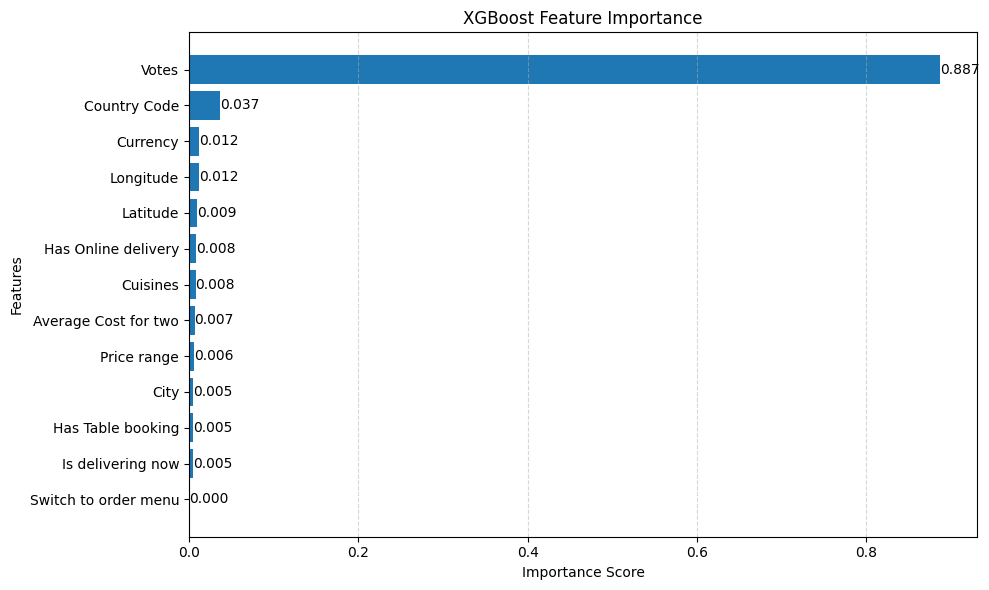

In [161]:
# XGBoost Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

for index, value in enumerate(importance["Importance"]):
    plt.text(value, index, f"{value:.3f}", va='center')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

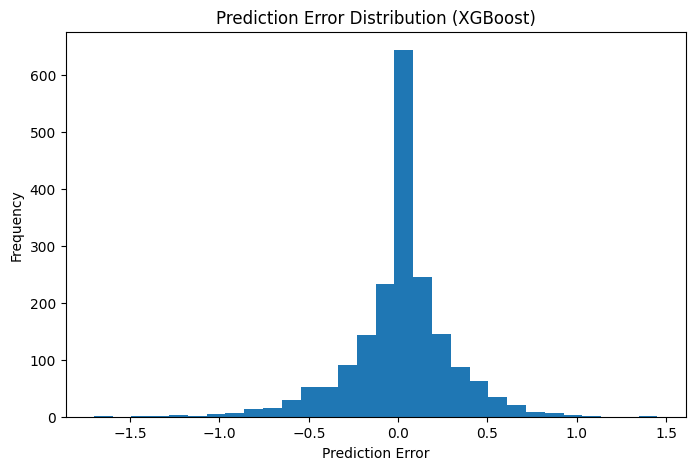

In [162]:
#Prediction Error Distribution
errors = y_test - xgb_pred

plt.figure(figsize=(8,5))

plt.hist(errors, bins=30)

plt.title("Prediction Error Distribution (XGBoost)")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

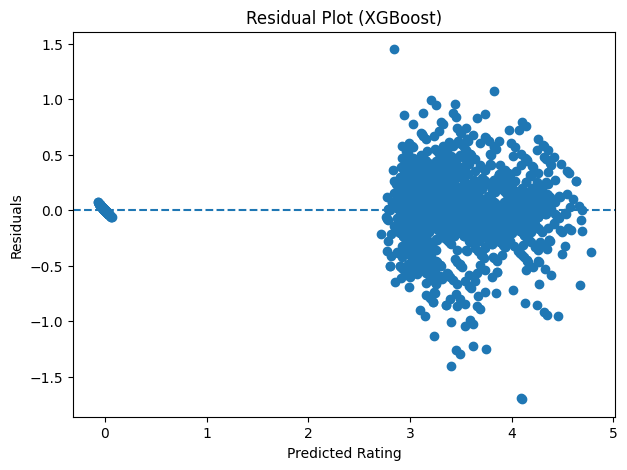

In [163]:
#Residual Plot
plt.figure(figsize=(7,5))

plt.scatter(xgb_pred, y_test - xgb_pred)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Rating")
plt.ylabel("Residuals")
plt.title("Residual Plot (XGBoost)")

plt.show()

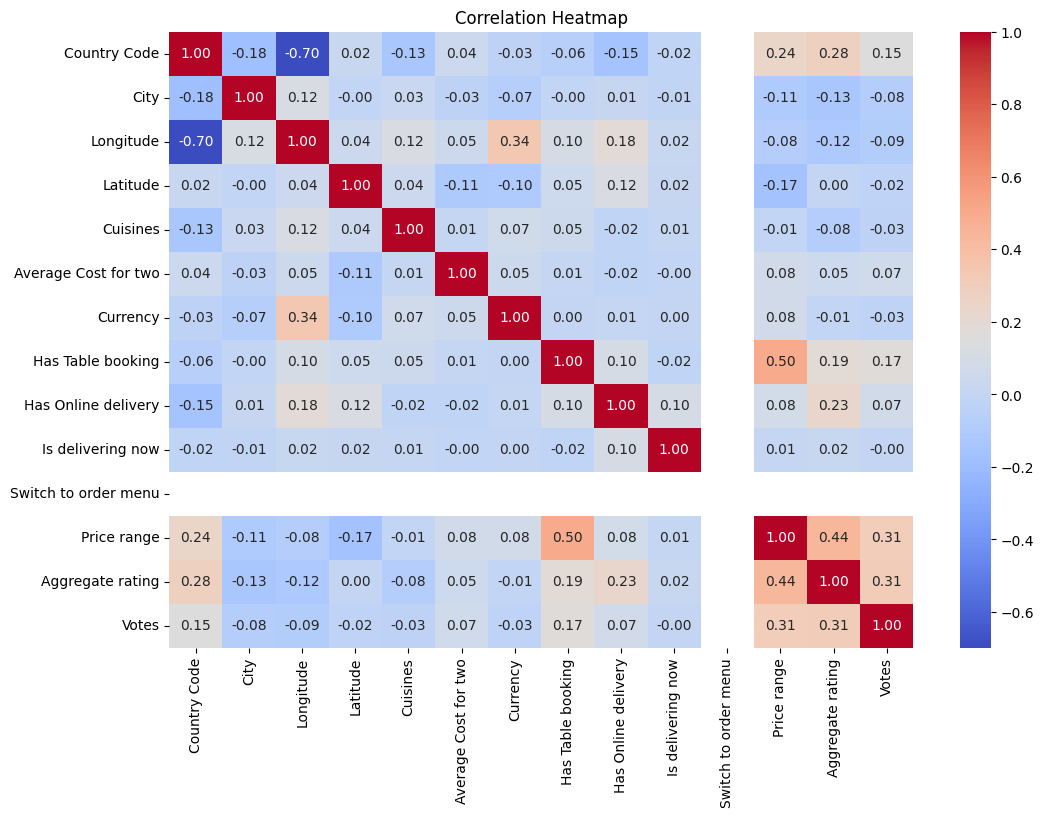

In [164]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [165]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(xgb, "xgboost_model.pkl")

print("Both models saved successfully!")

Both models saved successfully!
